# Chapter 19 - Dimensionality Reduction

Real-world datasets often contain many features. 

At first, this may look useful because more columns seem to carry more information.

In practice, too many features can make learning harder. 
- They can increase training time, reduce interpretability, encourage overfitting, and make the data space sparse.

In this chapter, we will study dimensionality reduction through two major ideas:

- Feature selection: keep only the most useful original features.
- Feature extraction: create a smaller set of new features from the original features.

We will use the Breast Cancer dataset from scikit-learn for the code demonstrations.

## Step 1 - Why Dimensionality Reduction Matters

Dimensionality means the number of features in a dataset. 
- A dataset with 30 columns has 30 dimensions.

More dimensions can create the `curse of dimensionality`. 
- As the number of features grows, data points spread out,
distances become less meaningful, and models may find it harder to learn reliable patterns.

Dimensionality reduction helps us focus on useful information while removing unnecessary complexity.

## Step 2 - Feature Selection and Feature Extraction

Feature selection keeps a subset of the original features. The selected columns still have their original meaning.

Feature extraction creates new features by combining or transforming the original ones. The new features may not match
any single original column, but they can capture the important structure in fewer dimensions.

- Firstly we will focus on wrapper methods and embedded methods for feature selection. 

- Then we will see PCA as it is the most common feature extraction method conceptually.

## Step 3 - Load the Breast Cancer Dataset

The Breast Cancer dataset contains 30 numeric features. We will use it to see whether feature selection can reduce the
number of columns without hurting model performance.

In [13]:
# import all the required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [14]:
# load the dataset with feature names so the outputs are easier to understand
dataset = load_breast_cancer()
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name="target")

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst five feature names:")
print(list(X.columns[:5]))

Dataset shape: (569, 30)
Target shape: (569,)

First five feature names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']


The dataset has 569 rows and 30 input features. 

This makes it a good example for learning feature selection.

## Step 4 - Create a Train-Test Split

We split the data before training so that model performance is measured on unseen data. 

The `stratify=y` argument keeps the class balance similar in both the training and test sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
    stratify=y,
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("\nNumber of features before selection:", X_train.shape[1])


Training rows: 455
Testing rows: 114

Number of features before selection: 30


## Step 5 - Baseline Logistic Regression With All Features

Before reducing features, we need a baseline. 

So, we train a simple Logistic Regression model using all 30 features.

It's accuracy becomes the reference point for all future comparisons.

In [16]:
baseline_model = LogisticRegression(max_iter=10000)
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline accuracy with all {X_train.shape[1]} features: {baseline_accuracy:.4f}")


Baseline accuracy with all 30 features: 0.9561


The baseline tells us how well Logistic Regression performs before any feature selection. 

Now we can check whether a smaller feature set can keep similar performance.

## Step 6 - Wrapper Method: Recursive Feature Elimination

Wrapper methods use a model to evaluate feature subsets. 

Recursive Feature Elimination, or RFE, repeatedly trains the model, ranks features, removes the weakest ones, and continues until the requested number of features remains.

Here we keep 15 out of the original 30 features.

In [25]:
rfe = RFE(
    estimator=LogisticRegression(max_iter=10000),
    n_features_to_select=15,
)

rfe.fit(X_train, y_train)

rfe_pred = rfe.predict(X_test)
rfe_accuracy = accuracy_score(y_test, rfe_pred)

print(f"RFE accuracy with 15 selected features: {rfe_accuracy:.4f}")
print(f"\nAccuracy difference from baseline: {rfe_accuracy - baseline_accuracy:.4f}")


RFE accuracy with 15 selected features: 0.9649

Accuracy difference from baseline: 0.0088


RFE has reduced the feature count by half. 

If the accuracy stays close to the baseline, it means many original features were redundant for this model and this dataset.

## Step 7 - Inspect the Features Selected by RFE

A useful advantage of feature selection is interpretability. 

Since RFE keeps original columns, we can directly see which features survived the selection process.

In [18]:
selected_features = X.columns[rfe.support_]
removed_features = X.columns[~rfe.support_]

print("Selected feature count:", len(selected_features))
print("Selected features:")
for feature in selected_features:
    print("-", feature)

print("\nFirst five removed features:")
print(list(removed_features[:5]))


Selected feature count: 15
Selected features:
- mean radius
- mean texture
- mean compactness
- mean concavity
- mean concave points
- mean symmetry
- texture error
- perimeter error
- worst texture
- worst perimeter
- worst smoothness
- worst compactness
- worst concavity
- worst concave points
- worst symmetry

First five removed features:
['mean perimeter', 'mean area', 'mean smoothness', 'mean fractal dimension', 'radius error']


The real dataset columns remain as selected features as a result of above technique.

This is the key difference between feature selection and feature extraction.

We have a smaller input space, but the selected columns still have their original meaning.

## Step 8 - Embedded Methods

Embedded methods perform feature selection during model training. There is no separate outer loop that tries many feature subsets.
The learning algorithm itself decides which features matter.

- Lasso can do this by shrinking weak coefficients to zero.
- Tree-based models can do this by preferring useful features while
creating splits. 

In this notebook, we use a Random Forest for demonstration.

In [19]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=1,
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest accuracy with all features: {rf_accuracy:.4f}")


Random Forest accuracy with all features: 0.9561


During training, the Random Forest repeatedly chooses useful features for tree splits. 

After training, we can inspect the importance score learned for each feature.

## Step 9 - Read Feature Importances

Feature importance values estimate how much each feature helped the forest reduce uncertainty across its trees.

Larger values indicate stronger influence in this trained model.

In [20]:
importance_df = pd.DataFrame(
    {
        "feature": X.columns,
        "importance": rf.feature_importances_,
    }
).sort_values(by="importance", ascending=False)

print("Top 10 Random Forest feature importances:")
print(importance_df.head(10).to_string(index=False))


Top 10 Random Forest feature importances:
             feature  importance
worst concave points    0.124769
     worst perimeter    0.120468
        worst radius    0.118810
          worst area    0.101692
 mean concave points    0.098063
      mean concavity    0.074643
         mean radius    0.050118
           mean area    0.046493
      mean perimeter    0.041984
     worst concavity    0.037304


These rankings are model-dependent. 
- A Random Forest may consider a feature important for its tree splits, while another model
may prefer a different subset. 

Feature selection is always tied to the model and task.

## Step 10 - Visualize the Top Embedded Feature Importances

A plot makes the ranking easier to compare. 

We show only the top 10 features so the chart stays readable.

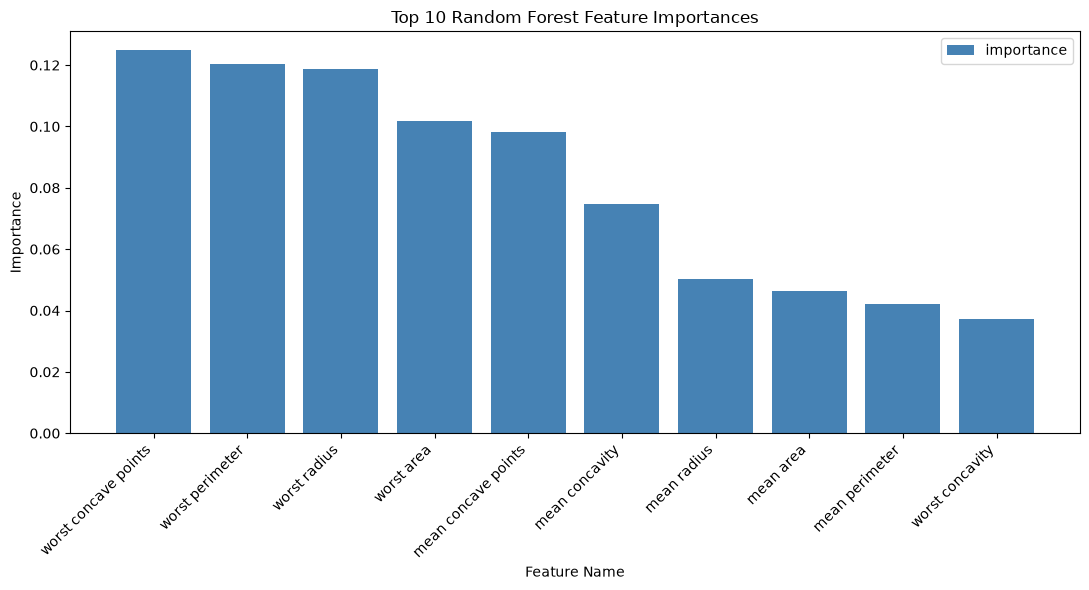

In [21]:
top_10_importance = importance_df.head(10)

plt.figure(figsize=(11, 6))
plt.bar(
    top_10_importance["feature"],
    top_10_importance["importance"],
    color="steelblue",
    label="importance",
)
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Feature Name")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


The tallest bars are the features that contributed most strongly inside this trained Random Forest. 

This is embedded feature selection because the ranking came from the model's own training process.

## Step 11 - Limitations of Feature Selection

Feature selection is powerful, but it can only keep or remove existing columns. 
- This becomes limiting when useful information is spread across several correlated features.
- In such cases, dropping columns can lose structure. 

Instead of selecting one column and discarding another, we may want to combine
them into a smaller set of new features. That leads to feature extraction.

## Step 12 - Feature Extraction and PCA

Feature extraction transforms the original feature space into a smaller new feature space. 

The new features are not simply selected columns. 

They are combinations of the original columns.

Principal Component Analysis, or PCA, is the most common feature extraction method. 
- It finds directions where the data varies the most and creates new axes called principal components.
- It rotate the feature space so that the first new direction captures the strongest pattern
in the data, and later directions capture smaller remaining patterns.

## Step 13 - PCA in Practice
  
Now let us apply PCA to the same Breast Cancer dataset and see how it reduces the feature space in practice.

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Original feature matrix shape:", X.shape)

# PCA is sensitive to feature scale, so we standardize the data first.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA without fixing the number of components first.
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("\nExplained variance ratio of first 10 components:")
print(explained_variance[:10])

print("\nCumulative explained variance ratio of first 10 components:")
print(cumulative_variance[:10])

Original feature matrix shape: (569, 30)

Explained variance ratio of first 10 components:
[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734 0.01588724 0.01389649 0.01168978]

Cumulative explained variance ratio of first 10 components:
[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881]


The principal components are new transformed features, not original columns.

The first few components capture most of the variation in the dataset.

The cumulative explained variance helps us decide how many components are enough.

In [23]:
# Reduce the 30 original features to 2 principal components.
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca_2d.shape)
print("\nExplained variance ratio of the 2 retained components:")
print(pca_2d.explained_variance_ratio_)
print("\nTotal variance captured by 2 components:", pca_2d.explained_variance_ratio_.sum())

Original shape: (569, 30)
Reduced shape: (569, 2)

Explained variance ratio of the 2 retained components:
[0.44272026 0.18971182]

Total variance captured by 2 components: 0.6324320765155944


After PCA, the dataset is compressed into 2 new dimensions.

These dimensions are combinations of the original 30 features.

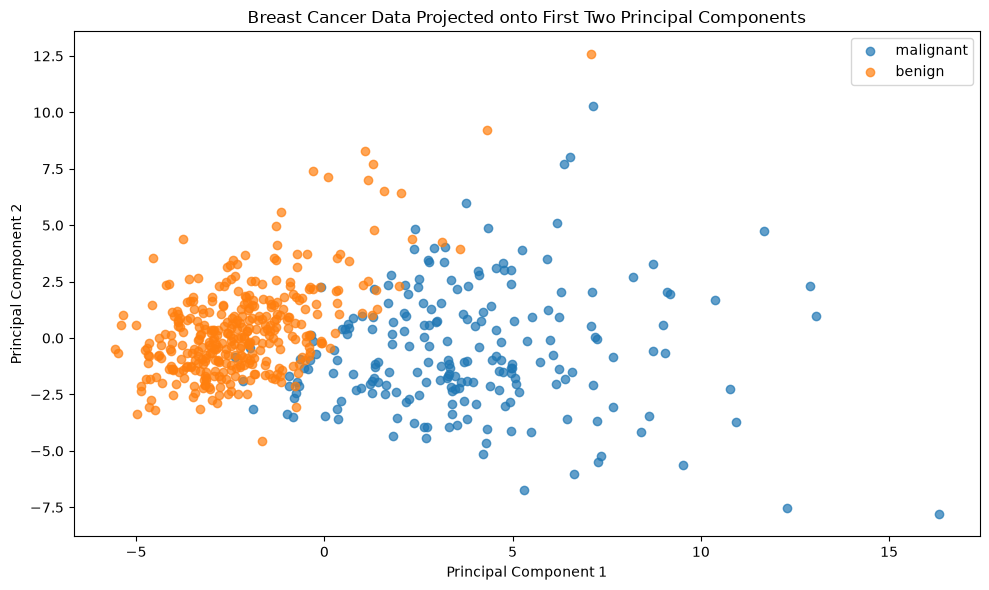

In [24]:
plt.figure(figsize=(10, 6))


for class_value, class_name in enumerate(dataset.target_names):
      plt.scatter(
          X_pca_2d[y == class_value, 0],
          X_pca_2d[y == class_value, 1],
          label=class_name,
          alpha=0.7,
      )


plt.title("Breast Cancer Data Projected onto First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

This plot shows how PCA transforms the original 30-feature dataset into a 2-dimensional representation. 

This is feature extraction because the new axes are combinations of the original features rather than selected original columns.

## Chapter Recap

In this chapter we learned the following ideas:

- Too many features can make learning slower, harder to interpret, and more prone to overfitting.
- Feature selection keeps useful original columns and removes less useful ones.
- Wrapper methods, such as RFE, evaluate feature subsets through a model.
- Embedded methods, such as Random Forest feature importance, select or rank features during training.
- Feature extraction creates new features by combining the original ones.
- PCA is a feature extraction method transformed the original features into a smaller set of principal components for compact representation and visualization.